In [93]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.feature_selection import RFECV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [94]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset_V3.csv')

X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [95]:
df

,address_line_2,h_id,n_seven_eleven_5km,n_gas_station_5km,n_cafe_5km,n_gas_station_in_3km_to_5km,near_Olympic_Stadium_in_km,n_secondary_school_5km,near_Phsar_Tmey_in_km,n_cafe_in_3km_to_5km,near_Phsar_Chas_in_km,near_Vattanac_Tower_in_km,n_pre_school_5km,near_Wat_Phnom_in_km,n_primary_school_in_3km_to_5km,price_per_m2
0,0,755,1.0,0.0,0.0,0,19.059819,0.0,17.992776,0,16.943040,16.949181,0.0,16.901875,0,271.001902
1,26,588,1.0,7.0,3.0,5,14.888674,2.0,15.827281,0,16.944827,15.882345,0.0,17.291293,0,577.242914
2,1,417,37.0,156.0,183.0,71,2.157976,78.0,1.104979,92,2.053186,0.917797,100.0,1.007210,33,2409.532237
3,59,554,-0.0,3.0,2.0,0,19.133051,-0.0,19.958459,0,19.894345,18.922889,0.0,19.988102,0,40.247299
4,17,172,4.0,27.0,22.0,18,8.014717,10.0,9.096619,16,9.964366,9.978901,1.0,10.095655,2,449.291560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1,419,29.0,134.0,164.0,70,2.162556,70.0,2.085419,80,1.918349,1.065358,89.0,0.915044,33,4659.297378
2996,63,340,8.0,21.0,14.0,15,10.215136,5.0,9.073913,8,9.048917,9.007038,4.0,9.104970,2,1400.269017
2997,77,418,32.0,118.0,156.0,61,2.884418,68.0,0.948316,80,1.208491,1.313799,84.0,0.999052,34,4204.623704
2998,11,439,34.0,152.0,178.0,77,1.856144,69.0,2.901031,98,4.200060,2.955867,91.0,4.085844,39,1443.499155


In [96]:
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

In [97]:
def gap_scoring(estimator, X, y):
    """Custom scoring function that minimizes the gap between train and test R²"""
    y_pred_train = estimator.predict(X)
    train_r2 = r2_score(y, y_pred_train)
    
    # Create a validation split
    X_train_val, X_val, y_train_val, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Fit on training portion and predict on validation
    estimator.fit(X_train_val, y_train_val)
    y_pred_val = estimator.predict(X_val)
    val_r2 = r2_score(y_val, y_pred_val)
    
    # Calculate the gap (we want to minimize this)
    gap = abs(train_r2 - val_r2)
    
    # Return a score that prioritizes small gap and good validation R²
    # Weighted combination: 70% validation R², 30% gap minimization
    return 0.70 * val_r2 - 0.30 * gap

In [98]:
def gap_sensitive_r2(estimator, X, y):
    # Split into train and test (30% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    # Fit model on training data
    estimator.fit(X_train, y_train)
    
    # Get predictions
    y_pred_train = estimator.predict(X_train)
    y_pred_test = estimator.predict(X_test)
    
    # Compute R² scores
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Calculate the gap (absolute difference)
    gap = abs(train_r2 - test_r2)
    
    # Penalize large gaps aggressively (exponential penalty)
    # If gap is small (e.g., < 0.02), reward test_r2
    # If gap is large (e.g., > 0.1), heavily penalize
    gap_penalty = 10.0 * gap ** 2  # Quadratic penalty (adjust multiplier for strictness)
    
    # Final score = test_r2 - gap_penalty
    score = test_r2 - gap_penalty
    
    # Ensure score is within bounds (R² can be negative)
    return max(score, -1.0)

In [99]:
def gap_scoring(estimator, X, y):
    """Custom scoring function that minimizes the gap between train and test R²"""
    y_pred_train = estimator.predict(X)
    train_r2 = r2_score(y, y_pred_train)
    
    # Create a validation split
    X_train_val, X_val, y_train_val, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Fit on training portion and predict on validation
    estimator.fit(X_train_val, y_train_val)
    y_pred_val = estimator.predict(X_val)
    val_r2 = r2_score(y_val, y_pred_val)
    
    # Calculate the gap (we want to minimize this)
    gap = abs(train_r2 - val_r2)
    
    # Return a score that prioritizes small gap and good validation R²
    # Weighted combination: 70% validation R²,d 30% gap minimization
    return 0.999 * val_r2 - 0.001 * gap

In [100]:
param_grid = {
    'n_estimators': [100, 200],                   # Keep it moderate
    'max_depth': [10, 15, 20],                    # Restrict tree depth
    'min_samples_split': [10, 20],                # Force larger internal nodes
    'min_samples_leaf': [6, 10],                  # Prevent tiny leaves
    'max_features': [0.4, 0.6],                   # Limit number of features per split
    'bootstrap': [True],
    'max_samples': [0.6, 0.8],                    # Encourage subsampling
    'ccp_alpha': [0.01, 0.05, 0.1]                # Increase pruning
}


In [101]:
rf_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring=gap_scoring,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'ccp_alpha': [0.01, 0.05, 0.1],
                                        'max_depth': [10, 15, 20],
                                        'max_features': [0.4, 0.6],
                                        'max_samples': [0.6, 0.8],
                                        'min_samples_leaf': [6, 10],
                                        'min_samples_split': [10, 20],
                                        'n_estimators': [100, 200]},
                   random_state=42,
                   scoring=<function gap_scoring at 0x000001D31C973BE0>,
                   verbose=1)

In [102]:
tuned_rf = rf_search.best_estimator_
best_params = rf_search.best_params_
print(f"Best R² from RandomizedSearchCV: {rf_search.best_score_:.4f}")
print(f"Best parameters: {best_params}")

Best R² from RandomizedSearchCV: 0.8405
Best parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_samples': 0.8, 'max_features': 0.4, 'max_depth': 10, 'ccp_alpha': 0.01, 'bootstrap': True}


In [103]:
y_pred_test = tuned_rf.predict(X_test)

In [104]:
r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
mape = np.mean(np.abs((y_test - y_pred_test) / np.maximum(y_test, 1e-8))) * 100 

In [105]:
print(f"Test R²: {r2:.4f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test MAPE: {mape:.2f}%")
print(f"Test Avg Price: {y_test.mean():.2f}")

Test R²: 0.8751
Test MAE: 390.22
Test MAPE: 49.34%
Test Avg Price: 1610.95


In [106]:
y_pred_train = tuned_rf.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
mae = mean_absolute_error(y_train, y_pred_train)
mape = np.mean(np.abs((y_train - y_pred_train) / np.maximum(y_train, 1e-8))) * 100 

In [107]:
print(f"Train R²: {r2_train:.4f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test MAPE: {mape:.2f}%")
print(f"Test Avg Price: {y_test.mean():.2f}")

Train R²: 0.9166
Test MAE: 306.68
Test MAPE: 43.74%
Test Avg Price: 1610.95


In [108]:
gap = r2_train - r2
print(f"Gap: {gap:.4f}")

Gap: 0.0415


In [109]:
# Evaluate on training set
y_train_pred = tuned_rf.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Evaluate on test set
y_test_pred = tuned_rf.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Train R² Score: {r2_train:.3f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test R² Score: {r2_test:.3f}")
print(f"Test RMSE: {rmse_test:.2f}")

Train R² Score: 0.917
Train RMSE: 516.18
Test R² Score: 0.875
Test RMSE: 634.42


[learning_curve] Training set sizes: [ 192  384  576  768  960 1152 1344 1536 1728 1920]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    8.0s finished


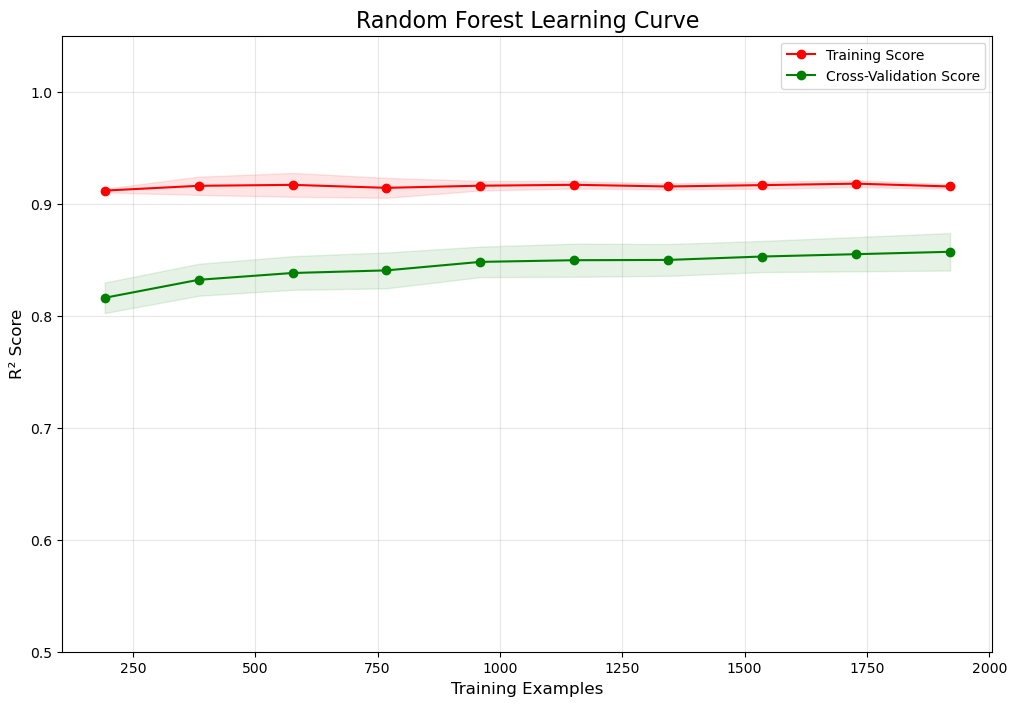

In [110]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=tuned_rf,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=5,  
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(12, 8))
plt.title("Random Forest Learning Curve", fontsize=16)
plt.xlabel("Training Examples", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.ylim(0.5, 1.05) 


plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.1,
    color="r"
)
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.1,
    color="g"
)

plt.plot(
    train_sizes,
    train_mean,
    'o-',
    color="r",
    label="Training Score"
)
plt.plot(
    train_sizes,
    val_mean,
    'o-',
    color="g",
    label="Cross-Validation Score"
)

plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.savefig("random_forest_learning_curve.png", dpi=300)
plt.show()

In [111]:

final_train_score = train_mean[-1]
final_val_score = val_mean[-1]
gap = final_train_score - final_val_score

In [112]:
print("\n" + "="*50)
print("Learning Curve Diagnostics:")
print(f"Final Training R²: {final_train_score:.4f}")
print(f"Final Validation R²: {final_val_score:.4f}")
print(f"Performance Gap: {gap:.4f}")



Learning Curve Diagnostics:
Final Training R²: 0.9154
Final Validation R²: 0.8571
Performance Gap: 0.0583


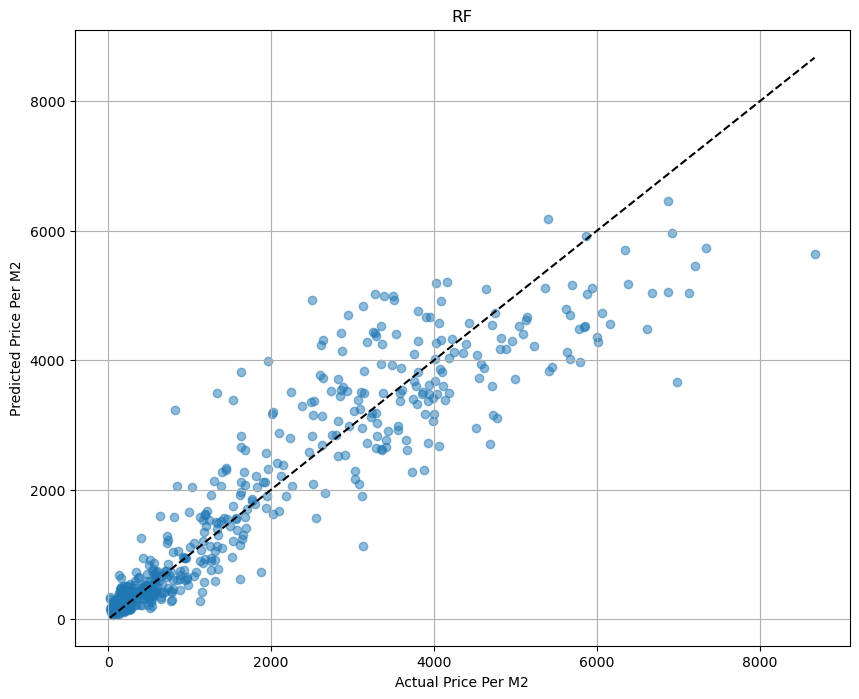

In [113]:
def plot_actual_vs_predicted(y_true, y_pred):
    plt.figure(figsize=(10, 8))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'k--')
    plt.xlabel('Actual Price Per M2')
    plt.ylabel('Predicted Price Per M2')
    plt.title('RF')
    plt.grid(True)
    plt.savefig("rf_actual_vs_predicted.png")
    plt.show()

plot_actual_vs_predicted(y_test, y_pred_test)

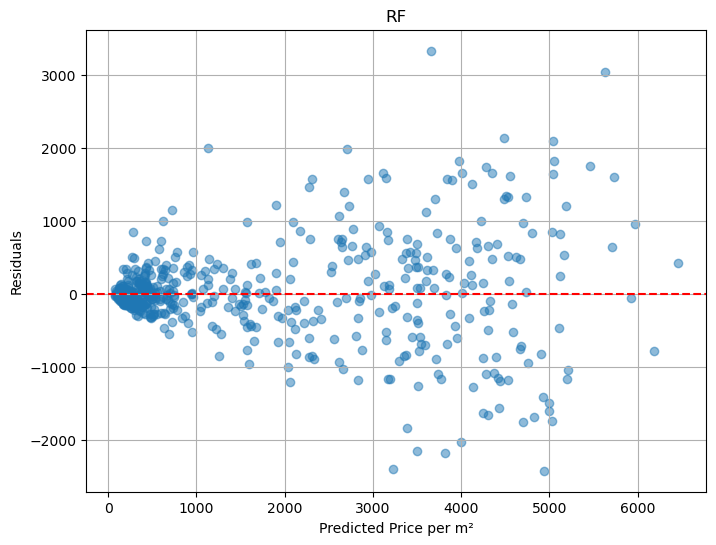

In [114]:
residuals = y_test - y_pred_test
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price per m²")
plt.ylabel("Residuals")
plt.title("RF")
plt.grid(True)
plt.show()

In [115]:
joblib.dump(tuned_rf, "../../../models/random_forest/random_forest_model_v7_label.joblib")

['../../../models/random_forest/random_forest_model_v7_label.joblib']